# Ensemble Learning

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import entropy
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

model_dir = Path('../models')
model_dir.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()

X_val = pd.read_csv('../data/processed/X_valid_scaled.csv')
y_val = pd.read_csv('../data/processed/y_valid.csv').values.ravel()

In [19]:
from sklearn.ensemble import AdaBoostRegressor, BaggingRegressor, StackingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Boosting

In [20]:
from sklearn.tree import DecisionTreeRegressor

boosting_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=50,
    random_state=42
)

boosting_model.fit(X_train, y_train)

with open(model_dir / 'boosting_model.pkl', 'wb') as f:
    pickle.dump(boosting_model, f)

print('AdaBoost model saved to ../models/boosting_model.pkl')

AdaBoost model saved to ../models/boosting_model.pkl


In [21]:
# evaluation on test output vs predict
boosting_pred = boosting_model.predict(X_val)

boosting_mae = mean_absolute_error(y_val, boosting_pred)
boosting_rmse = np.sqrt(mean_squared_error(y_val, boosting_pred))
boosting_r2 = r2_score(y_val, boosting_pred)

print("----- AdaBoost Report -----")
print(f"Mean Absolute Error: {boosting_mae:.4f}")
print(f"Root Mean Squared Error: {boosting_rmse:.4f}")
print(f"R2 Score: {boosting_r2:.4f}")

----- AdaBoost Report -----
Mean Absolute Error: 0.0979
Root Mean Squared Error: 0.1490
R2 Score: 0.8810


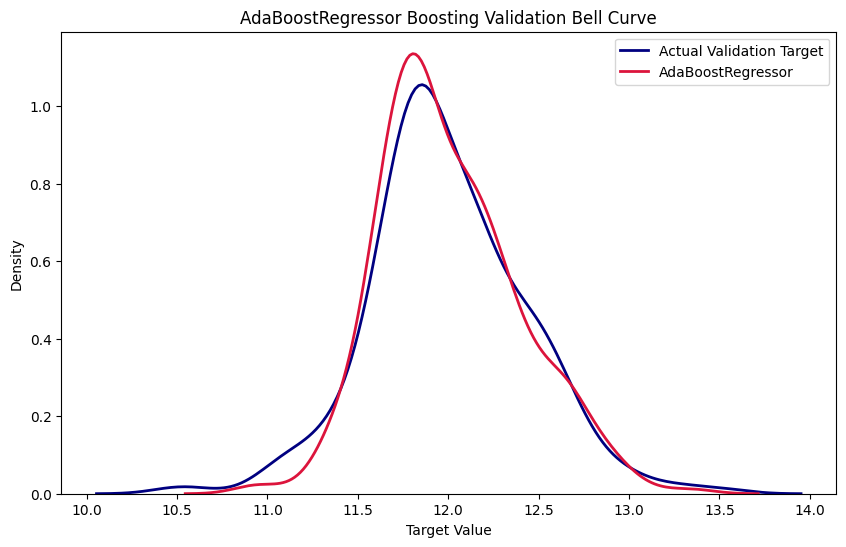

In [22]:
plt.figure(figsize=(10, 6))
sns.kdeplot(np.ravel(y_val), label='Actual Validation Target', linewidth=2, color='navy')
sns.kdeplot(np.ravel(boosting_pred), label='AdaBoostRegressor', linewidth=2, color='crimson')
plt.title('AdaBoostRegressor Boosting Validation Bell Curve')
plt.xlabel('Target Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## Bagging

In [23]:
from sklearn.tree import DecisionTreeRegressor

bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=50,
    random_state=42
)

bagging_model.fit(X_train, y_train)

with open(model_dir / 'bagging_model.pkl', 'wb') as f:
    pickle.dump(bagging_model, f)

print('Bagging model saved to ../models/bagging_model.pkl')

Bagging model saved to ../models/bagging_model.pkl


In [24]:
bagging_pred = bagging_model.predict(X_val)

bagging_mae = mean_absolute_error(y_val, bagging_pred)
bagging_rmse = np.sqrt(mean_squared_error(y_val, bagging_pred))
bagging_r2 = r2_score(y_val, bagging_pred)

print('----- Bagging Report -----')
print(f'Mean Absolute Error: {bagging_mae:.4f}')
print(f'Root Mean Squared Error: {bagging_rmse:.4f}')
print(f'R2 Score: {bagging_r2:.4f}')

----- Bagging Report -----
Mean Absolute Error: 0.1000
Root Mean Squared Error: 0.1502
R2 Score: 0.8791


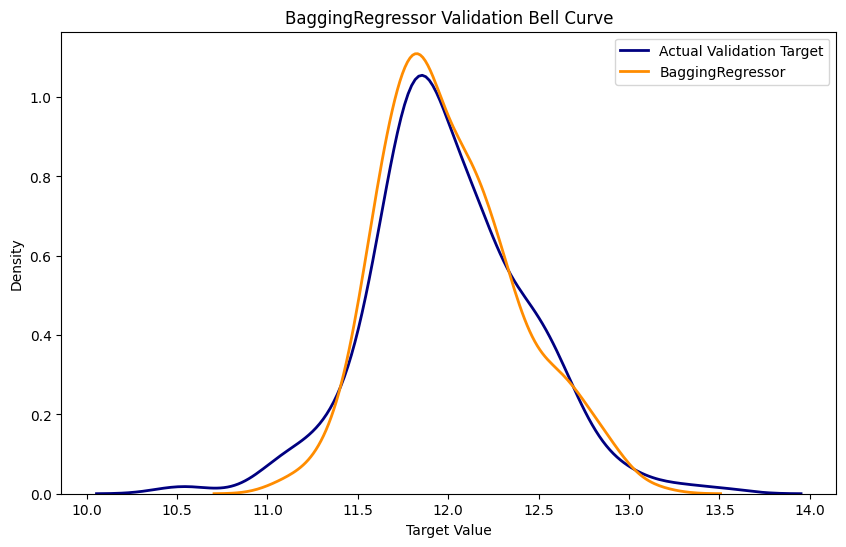

In [25]:
plt.figure(figsize=(10, 6))
sns.kdeplot(np.ravel(y_val), label='Actual Validation Target', linewidth=2, color='navy')
sns.kdeplot(np.ravel(bagging_pred), label='BaggingRegressor', linewidth=2, color='darkorange')
plt.title('BaggingRegressor Validation Bell Curve')
plt.xlabel('Target Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## Stacking

In [26]:
from sklearn.linear_model import LinearRegression

stacking_estimators = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeRegressor(random_state=42))
]

stacking_model = StackingRegressor(
    estimators=stacking_estimators,
    final_estimator=LinearRegression()
)

stacking_model.fit(X_train, y_train)

with open(model_dir / 'stacking_model.pkl', 'wb') as f:
    pickle.dump(stacking_model, f)

print('Stacking model saved to ../models/stacking_model.pkl')

Stacking model saved to ../models/stacking_model.pkl


In [27]:
stacking_pred = stacking_model.predict(X_val)

stacking_mae = mean_absolute_error(y_val, stacking_pred)
stacking_rmse = np.sqrt(mean_squared_error(y_val, stacking_pred))
stacking_r2 = r2_score(y_val, stacking_pred)

print('----- Stacking Report -----')
print(f'Mean Absolute Error: {stacking_mae:.4f}')
print(f'Root Mean Squared Error: {stacking_rmse:.4f}')
print(f'R2 Score: {stacking_r2:.4f}')

----- Stacking Report -----
Mean Absolute Error: 0.0939
Root Mean Squared Error: 0.1448
R2 Score: 0.8877


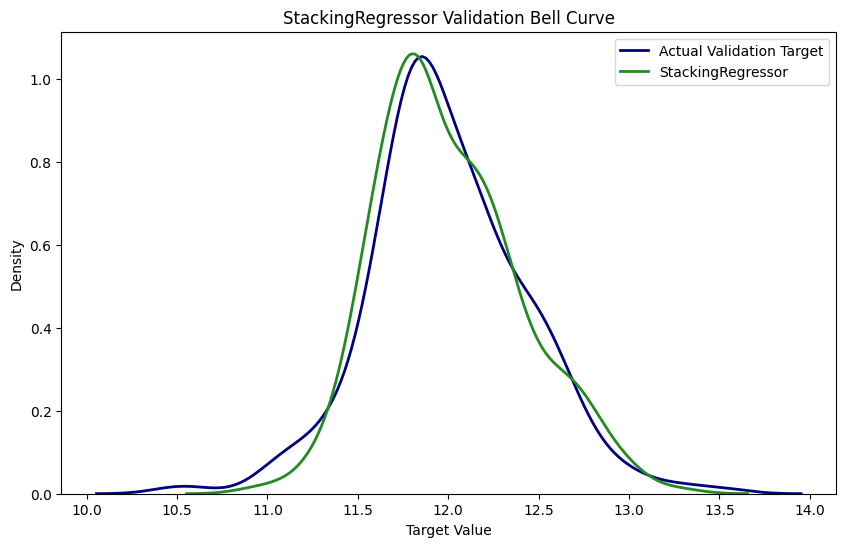

In [28]:
plt.figure(figsize=(10, 6))
sns.kdeplot(np.ravel(y_val), label='Actual Validation Target', linewidth=2, color='navy')
sns.kdeplot(np.ravel(stacking_pred), label='StackingRegressor', linewidth=2, color='forestgreen')
plt.title('StackingRegressor Validation Bell Curve')
plt.xlabel('Target Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## Voting

In [29]:
voting_estimators = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeRegressor(random_state=42))
]

voting_model = VotingRegressor(estimators=voting_estimators)

voting_model.fit(X_train, y_train)

with open(model_dir / 'voting_model.pkl', 'wb') as f:
    pickle.dump(voting_model, f)

print('Voting model saved to ../models/voting_model.pkl')

Voting model saved to ../models/voting_model.pkl


In [30]:
voting_pred = voting_model.predict(X_val)

voting_mae = mean_absolute_error(y_val, voting_pred)
voting_rmse = np.sqrt(mean_squared_error(y_val, voting_pred))
voting_r2 = r2_score(y_val, voting_pred)

print('----- Voting Report -----')
print(f'Mean Absolute Error: {voting_mae:.4f}')
print(f'Root Mean Squared Error: {voting_rmse:.4f}')
print(f'R2 Score: {voting_r2:.4f}')

----- Voting Report -----
Mean Absolute Error: 0.0988
Root Mean Squared Error: 0.1585
R2 Score: 0.8653


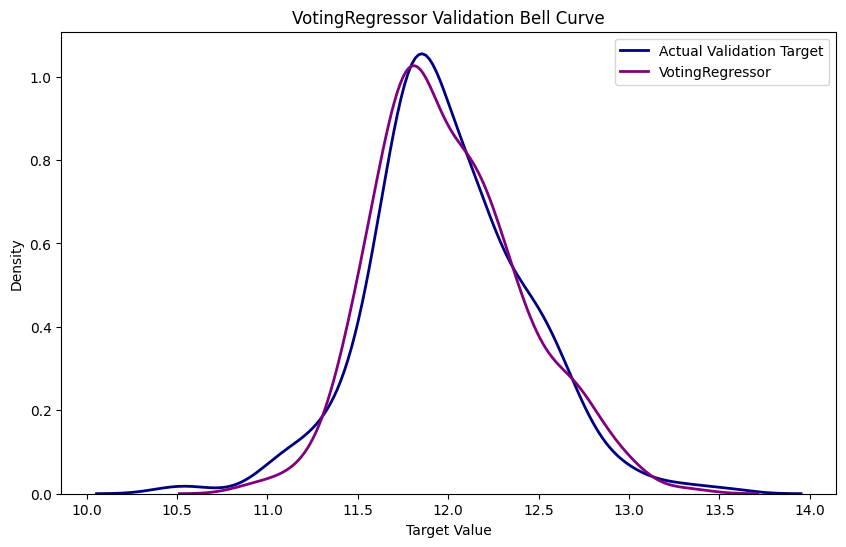

In [31]:
plt.figure(figsize=(10, 6))
sns.kdeplot(np.ravel(y_val), label='Actual Validation Target', linewidth=2, color='navy')
sns.kdeplot(np.ravel(voting_pred), label='VotingRegressor', linewidth=2, color='purple')
plt.title('VotingRegressor Validation Bell Curve')
plt.xlabel('Target Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## Accuracy Comparison

In [32]:
ensemble_results = pd.DataFrame({
    'Model': ['Boosting', 'Bagging', 'Stacking', 'Voting'],
    'MAE': [boosting_mae, bagging_mae, stacking_mae, voting_mae],
    'RMSE': [boosting_rmse, bagging_rmse, stacking_rmse, voting_rmse],
    'R2 Score': [boosting_r2, bagging_r2, stacking_r2, voting_r2]
})

ensemble_results = ensemble_results.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
ensemble_results['Accuracy (%)'] = ensemble_results['R2 Score'] * 100

display(ensemble_results)

,Model,MAE,RMSE,R2 Score,Accuracy (%)
0,Stacking,0.093907,0.144755,0.887714,88.771351
1,Boosting,0.097878,0.149044,0.880960,88.095979
2,Bagging,0.100018,0.150183,0.879135,87.913473
3,Voting,0.098754,0.158536,0.865316,86.531572
